# Multi-task Image Modeling with Timm + Fastai

This notebook demonstrates two distinct but foundational computer vision tasks using modern PyTorch-based tooling:

- ⭐️ Project 1: **Multi-label classification**: Assigning multiple object labels to a single image using **PASCAL VOC 2007**
- ⭐️ Project 2: **Image regression**: Estimating continuous values (e.g. spatial positions) from images using **BIWI Head Pose**

  
By placing these tasks together, we showcase:
- The flexibility of modern CV toolkits (Fastai + Timm)
- The ability to **adapt backbone CNNs across label formats and objectives**
- Engineering thinking to solve real-world diversity in output modalities

> ✅ This notebook shows the flexibility to extend fastai to non-standard tasks, integrate external model libraries (`timm`), and apply image modeling techniques beyond traditional classification.
> 
> 🔖 This notebook is designed to showcase a **versatile and professional deep learning workflow** across multiple CV problem types.



# ⭐️ Project 1 – Multi-label Image Classification with PASCAL VOC 2007

**Task**: Predict multiple object categories from a single image.

**Dataset**: PASCAL VOC 2007  
- 20 classes (e.g., person, car, dog...)  
- One image may contain multiple classes  
- Format: `JPEGImages/` + annotation CSV file

**Model**: `Timm` Models + `Fastai` Learner  
- Backbone: `ResNet`, `Efficientnet`
- Output: Sigmoid-activated multi-label head  
- Loss: `BCEWithLogitsLoss` (via fastai’s FlattenedLoss)

In [1]:
import timm
import pandas as pd
from fastai.vision.all import *
from functools import partial

In [2]:
#find the family model
res = timm.list_models('res*')
print(res)

['res2net50_14w_8s', 'res2net50_26w_4s', 'res2net50_26w_6s', 'res2net50_26w_8s', 'res2net50_48w_2s', 'res2net50d', 'res2net101_26w_4s', 'res2net101d', 'res2next50', 'resmlp_12_224', 'resmlp_24_224', 'resmlp_36_224', 'resmlp_big_24_224', 'resnest14d', 'resnest26d', 'resnest50d', 'resnest50d_1s4x24d', 'resnest50d_4s2x40d', 'resnest101e', 'resnest200e', 'resnest269e', 'resnet10t', 'resnet14t', 'resnet18', 'resnet18d', 'resnet26', 'resnet26d', 'resnet26t', 'resnet32ts', 'resnet33ts', 'resnet34', 'resnet34d', 'resnet50', 'resnet50_clip', 'resnet50_clip_gap', 'resnet50_gn', 'resnet50_mlp', 'resnet50c', 'resnet50d', 'resnet50s', 'resnet50t', 'resnet50x4_clip', 'resnet50x4_clip_gap', 'resnet50x16_clip', 'resnet50x16_clip_gap', 'resnet50x64_clip', 'resnet50x64_clip_gap', 'resnet51q', 'resnet61q', 'resnet101', 'resnet101_clip', 'resnet101_clip_gap', 'resnet101c', 'resnet101d', 'resnet101s', 'resnet152', 'resnet152c', 'resnet152d', 'resnet152s', 'resnet200', 'resnet200d', 'resnetaa34d', 'resnetaa

## Dataset - PASCAL 2007

Total 9963 images, containing 24640 annotated objects.

The 20 object classes that have been selected are:

- Person: person
- Animal: bird, cat, cow, dog, horse, sheep
- Vehicle: aeroplane, bicycle, boat, bus, car, motorbike, train
- Indoor: bottle, chair, dining table, potted plant, sofa, tv/monitor

In [68]:
path1 = untar_data(URLs.PASCAL_2007)

In [69]:
df = pd.read_csv(path1/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


In [70]:
df_test = pd.read_csv(path1/'test.csv')
df_test.describe()

,fname,labels
count,4952,4952
unique,4952,409
top,000001.jpg,person
freq,1,455


## Build DataBlock()

In [71]:
dblock = DataBlock()

dset = dblock.datasets(df)

print(len(dset.train), len(dset.valid))

4009 1002


In [72]:
x,y = dset.train[0]
x,y

(fname       009810.jpg
 labels             car
 is_valid         False
 Name: 4935, dtype: object,
 fname       009810.jpg
 labels             car
 is_valid         False
 Name: 4935, dtype: object)

In [73]:
v,w = dset.valid[0]
v,w

(fname       007590.jpg
 labels          person
 is_valid         False
 Name: 3825, dtype: object,
 fname       007590.jpg
 labels          person
 is_valid         False
 Name: 3825, dtype: object)

### DataBlock - functions

In [74]:
dblock = DataBlock(get_x = lambda r:r['fname'], get_y = lambda r:r['labels'])

In [75]:
def get_x(r): return r['fname']
def get_y(r): return r['labels']

In [76]:
dblock = DataBlock(get_x=get_x, get_y=get_y)

In [77]:
dset = dblock.datasets(df)
x,y = dset.train[0]
x,y

('002201.jpg', 'bus')

### Independent variables to open images
- ImageBlock
- MultiCategoryBlock

In [81]:
def get_x(r): return path1/'train'/r['fname']
def get_y(r): return r['labels'].split(' ')
dblock = DataBlock(get_x=get_x, get_y=get_y)
dset = dblock.datasets(df)
x,y = dset.train[0]
x,y

(Path('/Users/applewang/.fastai/data/pascal_2007/train/007812.jpg'), ['chair'])

In [82]:
dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                  get_x=get_x, get_y=get_y)
dset = dblock.datasets(df)

In [83]:
x,y = dset.train[0]
x,y

(PILImage mode=RGB size=500x358,
 TensorMultiCategory([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                      0., 0., 0., 0., 0.]))

find the idx and its category

In [84]:
idx = torch.where(dset.train[0][1]==1.)[0]

dset.train.vocab[idx]

(#1) ['bird']

### `Splitter` function 
split train/valid set

In [85]:
def splitter(df): 
    train = df.index[~df['is_valid']].tolist()
    valid = df.index[df['is_valid']].tolist()
    return train, valid


dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                  splitter=splitter, 
                   get_x=get_x, get_y=get_y,
                  item_tfms=Resize(128))

In [87]:
dls1 = dblock.dataloaders(df, bs=64)

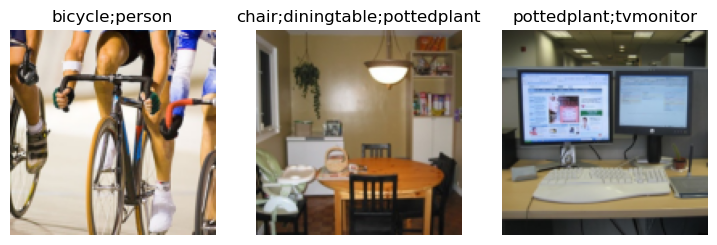

In [88]:
dls1.show_batch(max_n=3)

## Model training

**Model Design**

We use a `timm` backbone (EfficientNet B0) integrated into a `fastai` Learner.  
Key differences from standard classification:

- Output: `n_classes` independent sigmoid outputs
- Loss function: `BCEWithLogitsLossFlat()` for multi-label
- Metric: `accuracy_multi()` from fastai's `metrics` module (mean Average Precision)

```python
learn = vision_learner(
    dls,
    arch="tf_efficientnet_b0_ns",
    metrics=partial(APScoreMulti, thresh=0.4),
    loss_func=BCEWithLogitsLossFlat()
).to_fp16()

Base: ResNet18 (fastai)

In [89]:
learn = vision_learner(dls1, resnet18)

In [90]:
x,y = to_cpu(dls1.train.one_batch())

In [91]:
actives = learn.model(x)
actives.shape

torch.Size([64, 20])

In [92]:
actives[0].data

TensorImage([ 2.9105,  1.4947,  1.3830,  2.7300, -1.3011, -0.4582, -1.2138,
              2.1674,  2.3117,  6.3399,  0.7014, -1.7995,  3.1587,  1.6286,
             -1.1611,  1.5926, -2.6654,  0.7543,  2.2237,  5.8260])

In [93]:
y[0]

TensorMultiCategory([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
                     0., 0., 0., 0., 0.])

### Losses & Metrics using Fastai
**Loss functions** （Optimizing objective）
- Customed Binary cross-entropy `nn.BCEloss()` --Requires manual sigmoid() on logits. Prone to numerical instability.
  ```python
  def binary_cross_entropy(inputs, targets):
    inputs = inputs.sigmoid()
    return -torch.where(targets==1, inputs, 1-inputs).log().mean()```
    
- `nn.BCEWithLogitsLoss()` ✅ Recommended — combines sigmoid and BCE; uses log-sum-exp trick for stability.

    - Although not explicitly passed during model creation, `Fastai` automatically assigns the appropriate loss function based on the target data type.  
In this multi-label setting, the model uses:

```python
loss_func = BCEWithLogitsLoss() 
```

- `BCEWithLogitsLossFlat()`  - Fastai wrapper for `BCEWithLogitsLoss()`, ✅ used automatically with `MultiCategoryBlock`.


**Metrics** （Evaluating objective）
- `accuracy_multi()` -- for multi-labels accuracy evaluation, set sigmoid and its thresh.

### Resnet50

In [101]:
learn1 = vision_learner(dls1, resnet50, metrics=partial(accuracy_multi, thresh=0.2))

In [148]:
learn1.summary()

Sequential (Input shape: 64 x 3 x 128 x 128)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 64 x 64   
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 32 x 32   
MaxPool2d                                                      
Conv2d                                    4096       True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
____________________________________________________________________________
                     64 x 256 x 32 x 32  
Conv2d                                    16384      True      
BatchNorm2d                        

SuggestedLRs(valley=0.0020892962347716093)

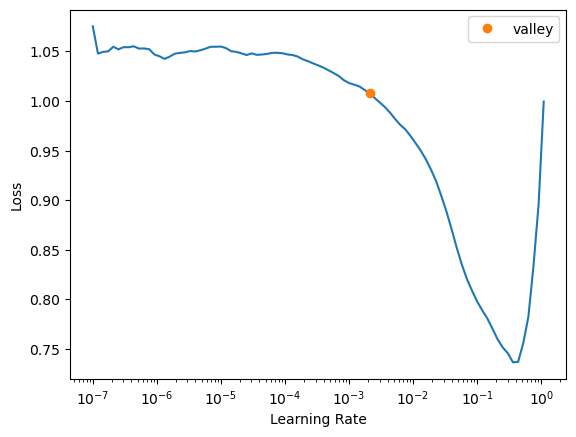

In [102]:
learn1.lr_find()

In [103]:
learn1.fine_tune(3, base_lr=3e-3, freeze_epochs=4)

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.957879,0.692117,0.225478,00:17
1,0.825802,0.548983,0.283586,00:15
2,0.601028,0.202379,0.808865,00:15
3,0.353539,0.118555,0.943526,00:15


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.119142,0.102614,0.955199,00:17
1,0.102824,0.099635,0.956793,00:17
2,0.084725,0.097590,0.958048,00:18


Check different thresh of `accuracy_multi` 

In [105]:
learn1.metrics = partial(accuracy_multi, thresh=0.1)
learn1.validate()

(#2) [0.09758982807397842,0.9415140151977539]

In [106]:
learn1.metrics = partial(accuracy_multi, thresh=0.9)
learn1.validate()

(#2) [0.09758982807397842,0.9583266377449036]

#### Predictions
of validation dataset

In [107]:
p1, t1 = learn1.get_preds()

In [108]:
accuracy_multi(p1, t1, thresh=0.8, sigmoid=False)

TensorBase(0.9631)

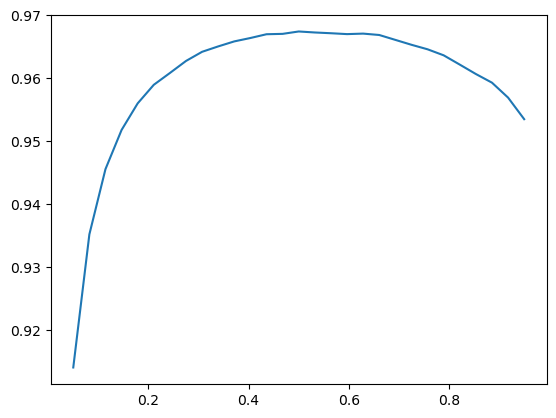

In [109]:
xs =torch.linspace(0.05, 0.95, 29)
accs = [accuracy_multi(p1, t1, thresh=i, sigmoid=False) for i in xs]
plt.plot(xs, accs);

From this plot, thresh=0.5, accuracy (multi) is greater 0.96+

### Resnetv2_50

In [114]:
learn2 = vision_learner(dls1, 
                       partial(timm.create_model, 'resnetv2_50', pretrained=True, num_classes=dls1.c),
                       metrics= partial(accuracy_multi, thresh=0.5))

In [115]:
learn2.fine_tune(3, 2e-3, freeze_epochs=3)

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.979416,0.694766,0.600140,00:16
1,0.853514,0.563441,0.726235,00:16
2,0.633215,0.246445,0.935876,00:15


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.265860,0.175939,0.950319,00:18
1,0.209646,0.146741,0.953924,00:19
2,0.178642,0.140322,0.954104,00:19


#### Predictions

In [116]:
p2, t2 = learn2.get_preds()

In [117]:
accuracy_multi(p2, t2, thresh=0.5, sigmoid=False)

TensorBase(0.9541)

### Efficientnet_b3
find models with key words and check which is suitable use `timm.list_models()`
```python
timm.list_models("efficientnet*") 

In [119]:
learn3 = vision_learner(dls1, 
                       partial(timm.create_model, 'efficientnet_b3', pretrained=True, num_classes=dls1.c),
                       metrics= partial(accuracy_multi, thresh=0.5))
learn3.fine_tune(3, 2e-3, freeze_epochs=3)

epoch,train_loss,valid_loss,accuracy_multi,time
0,1.024349,0.739749,0.574721,00:19
1,0.899718,0.601529,0.691355,00:19
2,0.681600,0.287062,0.915797,00:19


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.291657,0.202395,0.939064,00:22
1,0.238797,0.172302,0.941992,00:22
2,0.206206,0.169115,0.942251,00:22


In [120]:
p3, t3 = learn.get_preds()
accuracy_multi(p3, t3, thresh=0.5, sigmoid=False) 

TensorBase(0.8746)

### Model Comparison – Multi-label Image Classification (PASCAL VOC 2007)

| Model              | Acc.       | Pros                                                                 | Cons                                                                                      | Suitable Scenarios                            |
|--------------------|-----------------|----------------------------------------------------------------------|-------------------------------------------------------------------------------------------|------------------------------------------------|
| **ResNet50**        | 0.9580          | - Stable & fast<br>- Widely supported<br>- Good for fast deployment  | - Post-activation hinders very deep training<br>- Less robust for fine-grained datasets  | Baseline model for strong general-purpose tasks |
| **ResNetV2-50**     | 0.9541          | - Pre-activation aids gradient flow<br>- Slightly better regularization | - Slightly slower<br>- Fewer pretrained variants in some libraries                       | Training deep variants / improving stability   |
| **EfficientNet-B3** | 0.9422          | - Lightweight architecture<br>- Good accuracy-efficiency balance     | - More sensitive to image size<br>- Slower convergence without careful tuning            | Suitable for resource-constrained deployments  |

Although **ResNet50** achieved the highest mAP in this experiment, **ResNetV2-50** and **EfficientNet-B3** demonstrated competitive performance. EfficientNet-B3, while slightly behind in mAP, offers a smaller model size and energy-efficient inference, making it appealing for deployment on constrained devices.

All models were trained using Fastai + Timm with `BCEWithLogitsLoss` and `accuracy_multi` on PASCAL VOC 2007 dataset.

## 📙 Project 1 Conclusion

This section demonstrates how to build an effective multi-label image classification pipeline by combining Fastai and Timm.

- Used `BCEWithLogitsLoss` + `sigmoid` head for multi-hot labels
- Achieved strong performance across models:
    - ResNet50: 0.9580
	- ResNetV2-50: 0.9541
	- EfficientNet-B3: 0.9422
- Verified the ability of the model to identify multiple objects in a single image

> The pipeline is modular and reusable, suitable for other real-world datasets like MS-COCO or OpenImages where overlapping labels are common.
> 
> This task also highlights how Timm’s pretrained models can be easily integrated into Fastai workflows for flexible architecture experimentation.

# ⭐️ Project 2 – Image Regression on BIWI Head Pose

This project tackles an image regression task, where the *input* is an image and the *output* is one or more continuous values—in this case, the 3D position (x, y, z) of a person’s head in real-world space.

Unlike classification, regression predicts real-valued coordinates rather than discrete labels. Here we fine-tune a CNN model (via Fastai + Timm) to learn from facial images and regress the head center location, using MSELoss as the objective function.

> Image regression is a flexible and powerful paradigm that enables deep learning models to move beyond categorical decisions—supporting tasks like keypoint detection, 3D pose estimation, and physical measurement prediction.


**Task**: Predict the 3D head position (x, y, z) from a single RGB image.

**Dataset**: BIWI Head Pose Dataset
- RGB images of people with corresponding 3D head center coordinates
- Labels extracted from pose.txt (camera space position)
- Camera intrinsics loaded from rgb.cal
- Format: png images + numerical label files (float values)
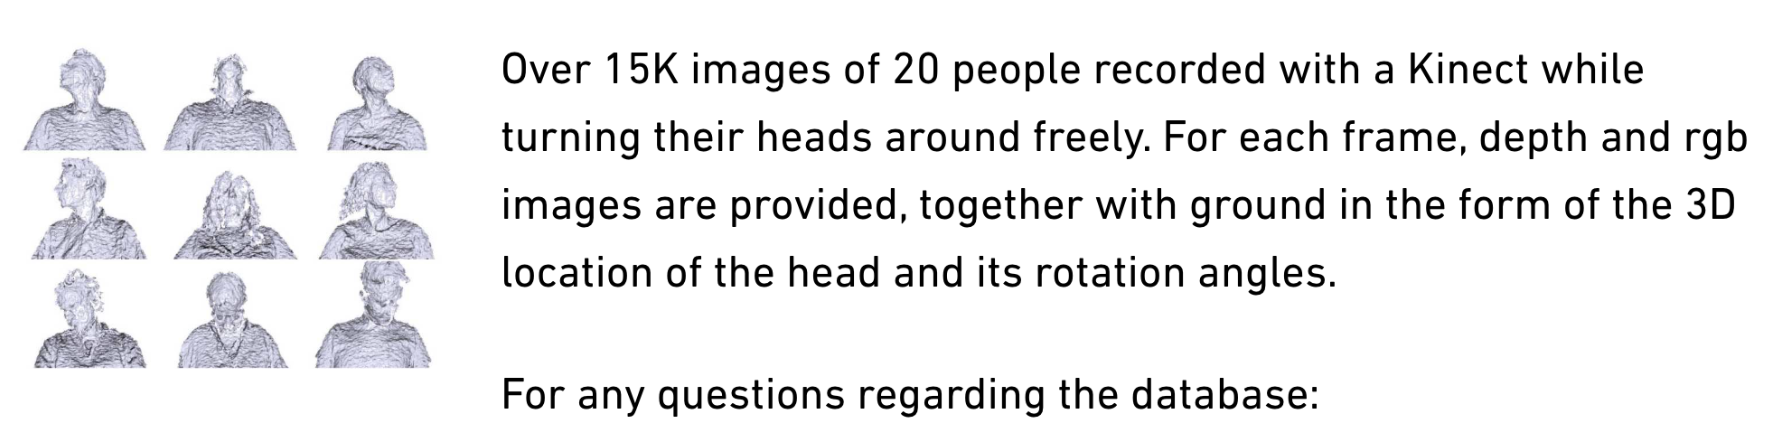
**Model**: `Timm` CNN backbones + `Fastai` Learner
- `ResNet18`


## Dataset preprocess

In [129]:
path2 = untar_data(URLs.BIWI_HEAD_POSE)
Path.BASE_PATH = path2

In [130]:
path2.ls().sorted()

(#51) [Path('.DS_Store'),Path('01'),Path('01.obj'),Path('02'),Path('02.obj'),Path('03'),Path('03.obj'),Path('04'),Path('04.obj'),Path('05')...]

In [131]:
(path2/'01').ls().sorted()

(#1000) [Path('01/depth.cal'),Path('01/frame_00003_pose.txt'),Path('01/frame_00003_rgb.jpg'),Path('01/frame_00004_pose.txt'),Path('01/frame_00004_rgb.jpg'),Path('01/frame_00005_pose.txt'),Path('01/frame_00005_rgb.jpg'),Path('01/frame_00006_pose.txt'),Path('01/frame_00006_rgb.jpg'),Path('01/frame_00007_pose.txt')...]

Each subfolder (e.g., '01') contains the following files per frame:
- pose.txt
    - Pose file containing the head’s pixel coordinates (x, y) and depth value (z)
    - The first 3 lines are comments
- rgb.jpg
    - RGB image file
- depth.cal
    - Extrinsic calibration matrix of the depth camera, used to map depth data into world coordinates or align with RGB frames.
- rgb.cal
    - Intrinsic calibration matrix of the RGB camera
    - This 3×3 matrix contains camera internal parameters such as focal length and principal point
    - The last 6 lines are comments

### `img2pose` function to get pose file
- xxxx_pose.txt is the target.

1. get the img file first eg. *Path('03/frame_00393_rgb.jpg')*
2. define a `img2pose` function: get the name (prefix) *03/frame_00393_* , then add the pose file (postfix) *pose.txt* 
3. get the pose file: *Path('03/frame_00393_pose.txt')*

In [132]:
imgs = get_image_files(path2) #get the images

In [133]:
imgs[0]

Path('03/frame_00393_rgb.jpg')

In [134]:
str(imgs[0])[:-7]

'/Users/applewang/.fastai/data/biwi_head_pose/03/frame_00393_'

In [135]:
def img2pose(x): return Path(f'{str(x)[:-7]}pose.txt')

In [136]:
img2pose(imgs[0])

Path('03/frame_00393_pose.txt')

### `get_tensor` function for y-label
- _pose.txt: x,y,z  - pixel coordinates (x, y) and depth value (z) - get from `img2pose` function
- rgb.cal - 3×3 matrix contains camera internal parameters - get from `np.genfromtxt('rgb.cal')`

>`get_tensor` function: Transform the "pixel coordinates" and "3x3 matrix" to the "camera's actual coordinates" (tensor) as y label

In [138]:
np.genfromtxt(path2/'01'/'rgb.cal', skip_footer=6) #skip last 6 comment lines

array([[517.679,   0.   , 320.   ],
       [  0.   , 517.679, 240.5  ],
       [  0.   ,   0.   ,   1.   ]])

In [147]:
cal = np.genfromtxt(path2/'01'/'rgb.cal', skip_footer=6)
def get_tensor(f): 
    ctr = np.genfromtxt(img2pose(f), skip_header=3)
    c1 = ctr[0]*cal[0][0]/ctr[2] + cal[0][2]
    c2 = ctr[1]*cal[1][1]/ctr[2] + cal[1][2]
    return tensor([c1, c2])

In [140]:
get_tensor(imgs[0])

tensor([387.1024, 261.9126])

### show an image

In [143]:
im1 = PILImage.create(imgs[5])
im1.shape

(480, 640)

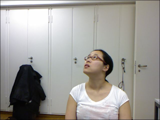

In [144]:
im1.to_thumb(160) #缩略图 to_thumb(size)

## Build a DataBlock()
- resize to half (speed up in training) -> aug_transform(size=(240,320))
- no random splitter (data had 20 people with much frames in 1 folder)
    - pick one person folder totally not in training, but validation.
    - use *FuncSplitter*
- **PointBlock**: its label represents coordinates!

In [56]:
PointBlock??

Type:            TransformBlock
String form:     <fastai.data.block.TransformBlock object at 0x30b2920d0>
File:            ~/miniconda3/envs/fastai/lib/python3.11/site-packages/fastai/data/block.py
Source:         
class TransformBlock():
    "A basic wrapper that links defaults transforms for the data block API"
    def __init__(self, 
        type_tfms:list=None, # One or more `Transform`s
        item_tfms:list=None, # `ItemTransform`s, applied on an item
        batch_tfms:list=None, # `Transform`s or `RandTransform`s, applied by batch
        dl_type:TfmdDL=None, # Task specific `TfmdDL`, defaults to `TfmdDL`
        dls_kwargs:dict=None, # Additional arguments to be passed to `DataLoaders`
    ):
        self.type_tfms  =            L(type_tfms)
        self.item_tfms  = ToTensor + L(item_tfms)
        self.batch_tfms =            L(batch_tfms)
        self.dl_type,self.dls_kwargs = dl_type,({} if dls_kwargs is None else dls_kwargs)
Class docstring: A basic wrapper that links def

In [57]:
FuncSplitter??

Signature: FuncSplitter(func)
Source:   
def FuncSplitter(func):
    "Split `items` by result of `func` (`True` for validation, `False` for training set)."
    def _inner(o):
        val_idx = mask2idxs(func(o_) for o_ in o)
        return IndexSplitter(val_idx)(o)
    return _inner
File:      ~/miniconda3/envs/fastai/lib/python3.11/site-packages/fastai/data/transforms.py
Type:      function

Under `DataBlock()`:
- `batch_tfms = aug_transform()` designed for GPU running; not in MacOS mps.
```python
biwi  = DataBlock(blocks=(ImageBlock, PointBlock),
                 get_items=get_image_files,
                  get_y=get_tensor,
                 splitter=FuncSplitter(lambda o: o.parent.name=='13'),
                    batch_tfms=aug_transform(Resize(240,320)))

In [58]:
biwi  = DataBlock(blocks=(ImageBlock, PointBlock),
                 get_items=get_image_files,
                  get_y=get_tensor,
                 splitter=FuncSplitter(lambda o: o.parent.name=='13'),
                    item_tfms=Resize(240,320))

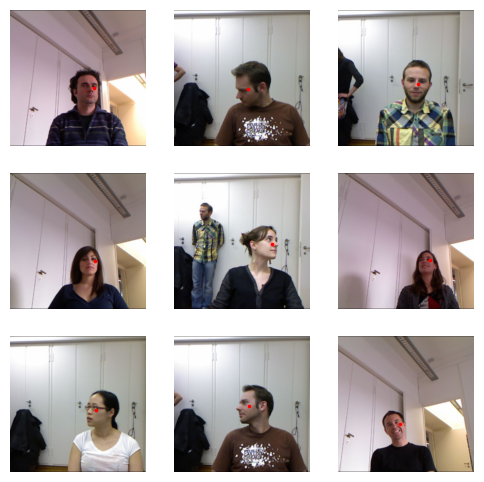

In [59]:
dls = biwi.dataloaders(path)
dls.show_batch(max_n=9, figsize=(6,6))

In [60]:
x,y = dls.one_batch()
x.shape, y.shape

(torch.Size([64, 3, 240, 240]), torch.Size([64, 1, 2]))

In [61]:
y[0]

TensorPoint([[0.1039, 0.2633]], device='mps:0')

## Model training
- y_range (coordinates in fastai and PyTorch are always rescaled between -1 and +1)
  

In [62]:
biwi_learner = vision_learner(dls, resnet18, y_range=(-1,1))

SuggestedLRs(valley=0.0005754399462603033)

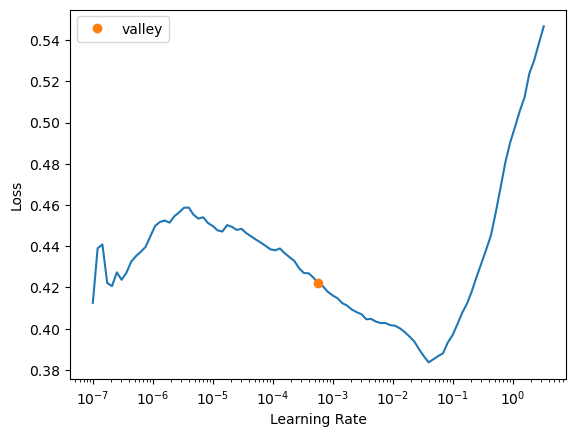

In [63]:
biwi_learner.lr_find()

In [64]:
lr = 0.002
biwi_learner.fine_tune(3, lr)

epoch,train_loss,valid_loss,time
0,0.121809,0.016091,01:11


epoch,train_loss,valid_loss,time
0,0.009894,0.000416,01:40
1,0.003760,0.000841,01:43
2,0.002357,0.000367,01:33


In [65]:
biwi_learner.loss_func

FlattenedLoss of MSELoss()

### Visual Evaluation

Instead of relying solely on quantitative metrics like MAE or RMSE, we opt for a visual evaluation approach.  
By overlaying the predicted head center point on each image, we can **directly assess** the model’s spatial accuracy in a more intuitive and interpretable way.

> ✅ This method is particularly effective in tasks like head pose estimation or keypoint detection, where visual alignment matters more than raw numbers.

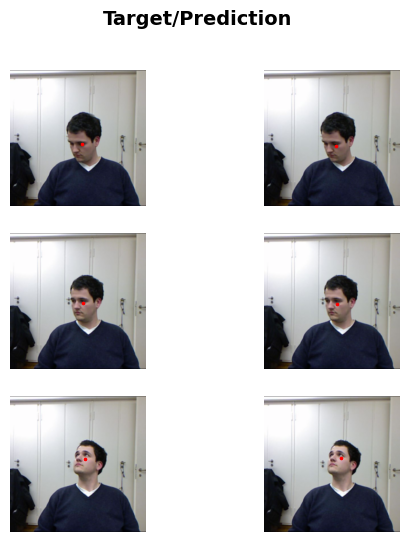

In [152]:
#show prediction: here is file '13'
biwi_learner.show_results(ds_idx=1, nrows=3, figsize=(6,6)) 

## 📙 Project 2 Conclusion

This project illustrates how to repurpose a convolutional backbone for **image-to-coordinate regression**, estimating (x, y, z) head positions from facial images.

- 📐 Task: Predict floating-point 3D coordinates
- 🧠 Output Head: Custom linear head without softmax or sigmoid
- 🧪 Loss: `MSELoss()` 

> This regression setup is essential in practical scenarios like **pose estimation, facial tracking, and AR/VR systems**.


# 📘 Final Summary

This notebook demonstrates how to apply modern deep learning pipelines to solve **two fundamentally different computer vision tasks**:

| Project     | Type                     | Output Format       | Loss Function         | Evaluation       |
|-------------|--------------------------|----------------------|------------------------|------------------|
| Project 1   | Multi-label classification | Multi-hot vector     | BCEWithLogitsLoss      | Accuracy_multi |
| Project 2   | Image regression          | 3D coordinates (x,y,z) | MSELoss                | show_results |

The entire workflow uses `Fastai` and `Timm` for high modularity and extensibility across CV problem types.
This notebook demonstrates practical readiness for deploying flexible CV pipelines across classification and regression challenges.